## Making a football fair team splitter

In [2]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [3]:
df = pd.read_csv('zoki_liga.csv')

In [4]:
df_test = pd.read_csv('zoki_liga_final.csv')

In [5]:
df_test

,index,name,position,matches,goals,assists,goal_contribution,gc_per_match,hat-trick,hat-trick-assists,...,penalty_stats,penalty_saves,w,w_percentage,losses,loss_percentage,motm,nominations,potm,gotm
0,1,Daco,D,36,5,11,16,0.44,0,0,...,0/0,0/1,13,0.36,16,0.44,3,1,1,0
1,2,Leo,D,34,40,19,59,1.74,3,3,...,0/1,1/2,12,0.35,16,0.47,3,2,3,1
2,3,Simikj,A,34,10,24,34,1.00,0,1,...,0/0,0/0,14,0.41,16,0.47,0,1,0,0
3,4,Stef,M,32,22,12,34,1.06,2,0,...,0/1,1/1,14,0.44,12,0.38,2,2,0,0
4,5,Neno,D,29,0,6,6,0.21,0,0,...,0/1,1/3,11,0.38,12,0.41,0,2,0,0
5,6,Prem,A,27,38,19,57,2.11,7,0,...,1/1,0/0,11,0.41,13,0.48,3,2,0,3
6,7,Borjan,M,27,31,19,50,1.85,4,1,...,0/1,0/0,17,0.63,8,0.30,0,0,0,0
7,8,Ancho,D,27,2,0,2,0.07,0,0,...,0/0,0/0,10,0.37,13,0.48,0,0,0,0
8,9,Hito,M,26,57,22,79,3.04,10,2,...,1/1,0/0,12,0.46,10,0.38,5,3,1,2
9,10,Hristijan,D,25,14,21,35,1.40,0,1,...,0/1,0/0,13,0.52,7,0.28,1,0,1,0


In [6]:
df = df.drop(columns=['index','matches','goal_contirbution','owngoals','freekicks','penalty_saves','penalty_stats','w','losses','nominations','gotm'])

In [7]:
df.head(5)

,name,position,goals,assists,gc_per_match,hat-trick,hat-trick-assists,w_percentage,loss_percentage,motm,potm,passing,physical,gk_ability,skill
0,Daco,G,4,7,0.44,0,0,32%,48%,0,0,3.5,5.5,7.5,1.50
1,Leo,D,30,15,1.96,3,3,43%,39%,3,2,7.0,8.5,0.0,4.00
2,Simikj,M,8,19,1.17,0,1,39%,52%,0,0,6.5,3.5,0.0,4.25
3,Stef,A,17,10,1.23,2,0,36%,45%,1,0,5.0,6.0,0.0,2.50
4,Neno,G,0,6,0.27,0,0,36%,41%,0,0,5.0,7.5,6.5,2.00


In [8]:
df['w_percentage'] = df['w_percentage'].str.replace('%','')

In [9]:
df['w_percentage'] = df['w_percentage'].astype(float)/100

In [10]:
df['w_percentage'] = df['w_percentage'].round(decimals=2)

In [11]:
df.head(10)

,name,position,goals,assists,gc_per_match,hat-trick,hat-trick-assists,w_percentage,loss_percentage,motm,potm,passing,physical,gk_ability,skill
0,Daco,G,4,7,0.44,0,0,0.32,48%,0,0,3.5,5.5,7.5,1.50
1,Leo,D,30,15,1.96,3,3,0.43,39%,3,2,7.0,8.5,0.0,4.00
2,Simikj,M,8,19,1.17,0,1,0.39,52%,0,0,6.5,3.5,0.0,4.25
3,Stef,A,17,10,1.23,2,0,0.36,45%,1,0,5.0,6.0,0.0,2.50
4,Neno,G,0,6,0.27,0,0,0.36,41%,0,0,5.0,7.5,6.5,2.00
5,Premcho,A,26,16,2.21,5,0,0.32,58%,1,0,7.5,7.0,0.0,4.50
6,Hito,A,48,15,3.50,10,2,0.50,33%,4,1,7.0,8.0,0.0,4.50
7,Borjan,M,21,12,1.90,3,0,0.59,35%,0,0,5.0,6.5,0.0,1.50
8,Ancho,D,2,0,0.12,0,0,0.41,41%,0,0,1.5,3.5,0.0,1.00
9,Joker,A,18,13,2.07,0,1,0.47,27%,1,0,6.5,4.0,0.0,3.50


In [12]:
df['loss_percentage'] = df['loss_percentage'].str.replace('%', '')
df['loss_percentage'] = df['loss_percentage'].astype(float) / 100
df['loss_percentage'] = df['loss_percentage'].round(decimals=2)

In [13]:
df.head(10)

,name,position,goals,assists,gc_per_match,hat-trick,hat-trick-assists,w_percentage,loss_percentage,motm,potm,passing,physical,gk_ability,skill
0,Daco,G,4,7,0.44,0,0,0.32,0.48,0,0,3.5,5.5,7.5,1.50
1,Leo,D,30,15,1.96,3,3,0.43,0.39,3,2,7.0,8.5,0.0,4.00
2,Simikj,M,8,19,1.17,0,1,0.39,0.52,0,0,6.5,3.5,0.0,4.25
3,Stef,A,17,10,1.23,2,0,0.36,0.45,1,0,5.0,6.0,0.0,2.50
4,Neno,G,0,6,0.27,0,0,0.36,0.41,0,0,5.0,7.5,6.5,2.00
5,Premcho,A,26,16,2.21,5,0,0.32,0.58,1,0,7.5,7.0,0.0,4.50
6,Hito,A,48,15,3.50,10,2,0.50,0.33,4,1,7.0,8.0,0.0,4.50
7,Borjan,M,21,12,1.90,3,0,0.59,0.35,0,0,5.0,6.5,0.0,1.50
8,Ancho,D,2,0,0.12,0,0,0.41,0.41,0,0,1.5,3.5,0.0,1.00
9,Joker,A,18,13,2.07,0,1,0.47,0.27,1,0,6.5,4.0,0.0,3.50


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               38 non-null     object 
 1   position           38 non-null     object 
 2   goals              38 non-null     int64  
 3   assists            38 non-null     int64  
 4   gc_per_match       38 non-null     float64
 5   hat-trick          38 non-null     int64  
 6   hat-trick-assists  38 non-null     int64  
 7   w_percentage       38 non-null     float64
 8   loss_percentage    38 non-null     float64
 9   motm               38 non-null     int64  
 10  potm               38 non-null     int64  
 11  passing            38 non-null     float64
 12  physical           38 non-null     float64
 13  gk_ability         38 non-null     float64
 14  skill              38 non-null     float64
dtypes: float64(7), int64(6), object(2)
memory usage: 4.6+ KB


## Attackers
The formula and the stats are set depending on the performance and on the attributes I think football is requiring for an ATTACKER to be complete.
I add more bias to the goals assists, to the physicality, to the skill and to passing

In [15]:
attackers = df[df['position'] == 'A']

In [16]:
attackers

,name,position,goals,assists,gc_per_match,hat-trick,hat-trick-assists,w_percentage,loss_percentage,motm,potm,passing,physical,gk_ability,skill
3,Stef,A,17,10,1.23,2,0,0.36,0.45,1,0,5.0,6.0,0.0,2.5
5,Premcho,A,26,16,2.21,5,0,0.32,0.58,1,0,7.5,7.0,0.0,4.5
6,Hito,A,48,15,3.50,10,2,0.50,0.33,4,1,7.0,8.0,0.0,4.5
9,Joker,A,18,13,2.07,0,1,0.47,0.27,1,0,6.5,4.0,0.0,3.5
14,Lazo,A,7,5,1.50,0,0,0.25,0.25,0,0,4.0,8.0,0.0,2.5
16,Dare,A,9,8,2.43,1,1,0.43,0.43,3,0,8.5,5.0,0.0,5.0
20,Ognen,A,4,3,1.75,0,0,0.25,0.75,0,0,6.5,5.5,0.0,4.5
22,Stojka,A,1,0,0.25,0,0,0.50,0.50,0,0,7.0,2.0,0.0,3.0
25,Vule,A,3,5,4.00,0,1,1.00,0.00,2,0,8.0,8.0,0.0,5.0
26,Nikec,A,1,2,1.50,0,0,0.50,0.00,0,0,5.5,5.5,0.0,2.5


In [17]:
weights_attack = {
    'goals': 0.6, 
    'assists': 0.4,
    'gc_per_match': 0.3, #prop included
    'passing': 0.2, #prop included
    'physical': 0.25, #prop included
    'motm': 1,  
    'potm': 3,  
    'w_percentage': 10,  
    'loss_percentage': 5,
    'win_loss':0.1, #prop included
    'skill':0.15 #prop included
}

attackers = attackers.assign(
    rating=(
        ((attackers['goals'] * weights_attack['goals'] +
          attackers['assists'] * weights_attack['assists']) * attackers['gc_per_match'] * weights_attack['gc_per_match']) +
        (attackers['passing'] * weights_attack['passing']) +
        (attackers['physical'] * weights_attack['physical']) +
        ((attackers['motm'] * weights_attack['motm'] + attackers['potm'] * weights_attack['potm'] +
          attackers['w_percentage'] * weights_attack['w_percentage'] - attackers['loss_percentage'] * weights_attack['loss_percentage']) * weights_attack['win_loss']) + 
        attackers['skill'] * (2 + weights_attack['skill'] )
    )
)


In [18]:
attackers = attackers.sort_values(by='rating', ascending=False)

In [19]:
attackers[['name','rating']]

,name,rating
6,Hito,50.6500
5,Premcho,27.6410
16,Dare,20.4844
9,Joker,20.1960
25,Vule,20.1100
20,Ognen,14.1150
3,Stef,13.3498
33,Tomas,12.3950
14,Lazo,11.0900
28,Teo,10.0500


In [20]:
# scaler_a = MinMaxScaler(feature_range=(1,10))
# scaler_a.fit(attackers[['rating']])
# attackers['rating'] = scaler_a.fit_transform(attackers[['rating']])
# attackers

In [21]:
attackers['rating'] = attackers['rating'].apply(lambda x: x*1.2 if x < 5 else x)

In [22]:
attackers[['name','rating']].round(3)

,name,rating
6,Hito,50.650
5,Premcho,27.641
16,Dare,20.484
9,Joker,20.196
25,Vule,20.110
20,Ognen,14.115
3,Stef,13.350
33,Tomas,12.395
14,Lazo,11.090
28,Teo,10.050


In [23]:
avg_attackers = round((attackers['rating'].sum())/attackers['rating'].size, 3)

In [24]:
avg_attackers

np.float64(16.62)

## Midfield

In [25]:
midfielders = df[df['position'] =='M']

In [26]:
midfielders

,name,position,goals,assists,gc_per_match,hat-trick,hat-trick-assists,w_percentage,loss_percentage,motm,potm,passing,physical,gk_ability,skill
2,Simikj,M,8,19,1.17,0,1,0.39,0.52,0,0,6.5,3.5,0.0,4.25
7,Borjan,M,21,12,1.90,3,0,0.59,0.35,0,0,5.0,6.5,0.0,1.50
17,Mario,M,8,5,2.17,0,0,0.67,0.17,3,0,6.0,8.0,0.0,4.00
18,Martin,M,7,5,2.40,2,0,0.20,0.60,3,0,8.0,8.5,0.0,4.50
23,Jancho,M,3,5,2.67,0,1,0.33,0.33,0,0,6.0,4.0,0.0,2.50
24,Davide,M,2,3,1.67,0,0,0.00,0.67,0,0,7.5,7.5,0.0,5.00
30,Theo,M,4,2,6.00,1,0,1.00,0.00,0,0,6.5,5.0,0.0,3.50
37,Leon,M,0,0,0.00,0,0,0.00,0.00,0,0,4.5,6.0,0.0,2.00


In [27]:
weights_midfielders = {
    'goals': 0.5, 
    'assists': 0.5,
    'gc_per_match': 0.25,#prop included
    'passing': 0.3, #prop included
    'physical': 0.2, #prop included
    'motm': 1,  
    'potm': 3,  
    'w_percentage': 10,  
    'loss_percentage': 5,
    'win_loss':0.1, #prop included
    'skill':0.15 #prop included
}

midfielders = midfielders.assign(
    rating=(
        ((midfielders['goals'] * weights_midfielders['goals'] +
          midfielders['assists'] * weights_midfielders['assists']) * midfielders['gc_per_match'] * weights_midfielders['gc_per_match']) +
        (midfielders['passing'] * weights_midfielders['passing']) +
        (midfielders['physical'] * weights_midfielders['physical']) +
        ((midfielders['motm'] * weights_midfielders['motm'] + midfielders['potm'] * weights_midfielders['potm'] +
          midfielders['w_percentage'] * weights_midfielders['w_percentage'] - midfielders['loss_percentage'] * weights_midfielders['loss_percentage']) * weights_midfielders['win_loss']) + 
        midfielders['skill'] * (3 + weights_midfielders['skill'] )
    )
)


In [28]:
midfielders = midfielders.sort_values(by='rating', ascending=False)

In [29]:
midfielders[['name','rating']].round(3)

,name,rating
18,Martin,22.075
17,Mario,20.411
24,Davide,20.209
2,Simikj,20.116
30,Theo,19.475
7,Borjan,15.777
23,Jancho,13.310
37,Leon,8.850


In [30]:
# scaler_m = MinMaxScaler(feature_range=(1,10))
# scaler_m.fit(midfielders[['rating']])
# midfielders['rating'] = scaler_m.fit_transform(midfielders[['rating']])

In [31]:
midfielders[['name','rating']].round(3)

,name,rating
18,Martin,22.075
17,Mario,20.411
24,Davide,20.209
2,Simikj,20.116
30,Theo,19.475
7,Borjan,15.777
23,Jancho,13.310
37,Leon,8.850


In [32]:
# midfielders['rating'] = midfielders['rating'].apply(lambda x: x*1.2 if x < 5 else x)

In [33]:
midfielders[['name','rating']].round(3)

,name,rating
18,Martin,22.075
17,Mario,20.411
24,Davide,20.209
2,Simikj,20.116
30,Theo,19.475
7,Borjan,15.777
23,Jancho,13.310
37,Leon,8.850


In [34]:
avg_midfielders = round((midfielders['rating'].sum())/midfielders['rating'].size, 3)

In [35]:
avg_midfielders

np.float64(17.528)

## Defenders

In [36]:
defenders = df[df['position'] =='D']

In [37]:
defenders

,name,position,goals,assists,gc_per_match,hat-trick,hat-trick-assists,w_percentage,loss_percentage,motm,potm,passing,physical,gk_ability,skill
1,Leo,D,30,15,1.96,3,3,0.43,0.39,3,2,7.0,8.5,0.0,4.0
8,Ancho,D,2,0,0.12,0,0,0.41,0.41,0,0,1.5,3.5,0.0,1.0
10,Shulz,D,8,11,1.19,0,1,0.50,0.25,1,1,6.5,8.5,0.0,3.0
11,Maki,D,4,11,1.00,0,1,0.53,0.33,2,1,5.5,6.5,0.0,4.0
12,Grekos,D,7,3,0.71,0,0,0.21,0.57,0,0,4.0,5.5,0.0,2.5
13,Bale,D,1,2,0.30,0,0,0.30,0.40,1,0,2.0,9.0,0.0,1.0
34,Tagar,D,1,0,1.00,0,0,1.00,0.00,0,0,3.0,7.0,0.0,1.0
35,Gorjan,D,0,0,0.00,0,0,0.00,1.00,0,0,3.5,8.0,0.0,1.5
36,Hris,D,0,0,0.00,0,0,0.00,1.00,0,0,2.0,5.0,0.0,1.0


In [38]:
weight_defenders = {
    'goals': 0.5, 
    'assists': 0.5,
    'gc_per_match': 0.25,#prop included
    'passing': 0.27, #prop included
    'physical': 0.25, #prop included
    'motm': 1,  
    'potm': 3,  
    'w_percentage': 10,  
    'loss_percentage': 5,
    'win_loss':0.1, #prop included
    'skill':0.13 #prop included
}

defenders = defenders.assign(
    rating=(
        ((defenders['goals'] * weight_defenders['goals'] +
          defenders['assists'] * weight_defenders['assists']) * defenders['gc_per_match'] * weight_defenders['gc_per_match']) +
        (defenders['passing'] * weight_defenders['passing']) +
        (defenders['physical'] * weight_defenders['physical']) +
        ((defenders['motm'] * weight_defenders['motm'] + defenders['potm'] * weight_defenders['potm'] +
          defenders['w_percentage'] * weight_defenders['w_percentage'] - defenders['loss_percentage'] * weight_defenders['loss_percentage']) * weight_defenders['win_loss']) + 
        defenders['skill'] * (3 + weight_defenders['skill'] )
    )
)


In [39]:
defenders = defenders.sort_values(by='rating', ascending=False)

In [40]:
defenders[['name','rating']].round(3)

,name,rating
1,Leo,28.695
11,Maki,18.370
10,Shulz,16.871
12,Grekos,11.092
35,Gorjan,7.140
34,Tagar,6.815
13,Bale,6.232
8,Ancho,4.645
36,Hris,4.420


In [41]:
# scaler_d = MinMaxScaler(feature_range=(1,10))
# scaler_d.fit(defenders[['rating']])
# defenders['rating'] = scaler_d.fit_transform(defenders[['rating']])

In [42]:
avg_defenders = round((defenders['rating'].sum())/defenders['rating'].size, 3)

In [43]:
avg_defenders

np.float64(11.587)

In [44]:
# defenders['rating'] = defenders['rating'].apply(lambda x: x*1.2 if x < 5 else x)

In [45]:
defenders[['name','rating']].round(3)

,name,rating
1,Leo,28.695
11,Maki,18.370
10,Shulz,16.871
12,Grekos,11.092
35,Gorjan,7.140
34,Tagar,6.815
13,Bale,6.232
8,Ancho,4.645
36,Hris,4.420


## Goalkeepers

In [46]:
goalkeepers = df[df['position'] =='G']

In [47]:
goalkeepers

,name,position,goals,assists,gc_per_match,hat-trick,hat-trick-assists,w_percentage,loss_percentage,motm,potm,passing,physical,gk_ability,skill
0,Daco,G,4,7,0.44,0,0,0.32,0.48,0,0,3.5,5.5,7.5,1.5
4,Neno,G,0,6,0.27,0,0,0.36,0.41,0,0,5.0,7.5,6.5,2.0
15,Stec,G,0,1,0.11,0,0,0.67,0.22,2,0,1.5,1.0,6.5,1.0
19,Fich,G,1,0,0.20,0,0,0.20,0.80,0,0,4.0,6.0,6.0,2.0
21,Nuh,G,0,1,0.25,0,0,0.50,0.50,0,0,1.5,3.0,5.0,1.0
27,Fish,G,0,0,0.00,0,0,0.50,0.50,0,0,1.0,1.5,2.0,1.0
29,Silbo,G,0,0,0.00,0,0,0.50,0.00,1,0,3.5,7.5,6.0,1.0


In [48]:
goalkeepers[['name','gk_ability']].round(3)

,name,gk_ability
0,Daco,7.5
4,Neno,6.5
15,Stec,6.5
19,Fich,6.0
21,Nuh,5.0
27,Fish,2.0
29,Silbo,6.0


In [49]:
weights_goalkeepers = {
    'gk_ability': 0.6, #prop included
    'passing': 0.1, #prop included
    'physical': 0.1, #prop included
    'goal_contribution':0.1,
    'motm': 2,  
    'potm': 4,  
    'w_percentage': 10,  
    'loss_percentage': 5,
    'win_loss':0.1, #prop included
}

goalkeepers = goalkeepers.assign(
    rating=(
        (goalkeepers['goals'] + goalkeepers['assists']) * weights_goalkeepers['goal_contribution'] + 
        goalkeepers['gk_ability'] * 2 +
        (goalkeepers['w_percentage'] * weights_goalkeepers['w_percentage'] + goalkeepers['loss_percentage'] * weights_goalkeepers['loss_percentage'])*weights_goalkeepers['win_loss'] +
        goalkeepers['passing'] * weights_goalkeepers['passing'] + goalkeepers['physical'] * weights_goalkeepers['physical'] +
        goalkeepers['motm'] * weights_goalkeepers['motm'] +
        goalkeepers['potm'] * weights_goalkeepers['potm']
    )
)


In [50]:
goalkeepers = goalkeepers.sort_values(by='rating', ascending=False)

In [51]:
# scaler_gk = MinMaxScaler(feature_range=(1,10))
# scaler_gk.fit(goalkeepers[['rating']])
# goalkeepers['rating'] = scaler_gk.fit_transform(goalkeepers[['rating']])

In [52]:
# goalkeepers['rating'] = goalkeepers['rating'].apply(lambda x: x*1.2 if x < 5 else x)

In [53]:
goalkeepers[['name','rating']].round(3)

,name,rating
15,Stec,18.130
0,Daco,17.560
29,Silbo,15.600
4,Neno,15.415
19,Fich,13.700
21,Nuh,11.300
27,Fish,5.000


## Merging the ratings

In [54]:
df_with_ratings = pd.concat([goalkeepers,defenders,midfielders,attackers], ignore_index=True)

In [55]:
df_with_ratings

,name,position,goals,assists,gc_per_match,hat-trick,hat-trick-assists,w_percentage,loss_percentage,motm,potm,passing,physical,gk_ability,skill,rating
0,Stec,G,0,1,0.11,0,0,0.67,0.22,2,0,1.5,1.0,6.5,1.00,18.13000
1,Daco,G,4,7,0.44,0,0,0.32,0.48,0,0,3.5,5.5,7.5,1.50,17.56000
2,Silbo,G,0,0,0.00,0,0,0.50,0.00,1,0,3.5,7.5,6.0,1.00,15.60000
3,Neno,G,0,6,0.27,0,0,0.36,0.41,0,0,5.0,7.5,6.5,2.00,15.41500
4,Fich,G,1,0,0.20,0,0,0.20,0.80,0,0,4.0,6.0,6.0,2.00,13.70000
5,Nuh,G,0,1,0.25,0,0,0.50,0.50,0,0,1.5,3.0,5.0,1.00,11.30000
6,Fish,G,0,0,0.00,0,0,0.50,0.50,0,0,1.0,1.5,2.0,1.00,5.00000
7,Leo,D,30,15,1.96,3,3,0.43,0.39,3,2,7.0,8.5,0.0,4.00,28.69500
8,Maki,D,4,11,1.00,0,1,0.53,0.33,2,1,5.5,6.5,0.0,4.00,18.37000
9,Shulz,D,8,11,1.19,0,1,0.50,0.25,1,1,6.5,8.5,0.0,3.00,16.87125


In [56]:
# scaler = MinMaxScaler(feature_range=(1,10))
# scaler.fit(df_with_ratings[['rating']])
# df_with_ratings['rating'] = scaler.fit_transform(df_with_ratings[['rating']])

In [57]:
# df_with_ratings = df_with_ratings[['name','rating']].round(3)

In [58]:
df_with_ratings.sort_values(by='rating',ascending=False)

,name,position,goals,assists,gc_per_match,hat-trick,hat-trick-assists,w_percentage,loss_percentage,motm,potm,passing,physical,gk_ability,skill,rating
24,Hito,A,48,15,3.50,10,2,0.50,0.33,4,1,7.0,8.0,0.0,4.50,50.65000
7,Leo,D,30,15,1.96,3,3,0.43,0.39,3,2,7.0,8.5,0.0,4.00,28.69500
25,Premcho,A,26,16,2.21,5,0,0.32,0.58,1,0,7.5,7.0,0.0,4.50,27.64100
16,Martin,M,7,5,2.40,2,0,0.20,0.60,3,0,8.0,8.5,0.0,4.50,22.07500
26,Dare,A,9,8,2.43,1,1,0.43,0.43,3,0,8.5,5.0,0.0,5.00,20.48440
17,Mario,M,8,5,2.17,0,0,0.67,0.17,3,0,6.0,8.0,0.0,4.00,20.41125
18,Davide,M,2,3,1.67,0,0,0.00,0.67,0,0,7.5,7.5,0.0,5.00,20.20875
27,Joker,A,18,13,2.07,0,1,0.47,0.27,1,0,6.5,4.0,0.0,3.50,20.19600
19,Simikj,M,8,19,1.17,0,1,0.39,0.52,0,0,6.5,3.5,0.0,4.25,20.11625
28,Vule,A,3,5,4.00,0,1,1.00,0.00,2,0,8.0,8.0,0.0,5.00,20.11000


## Selected players

In [59]:
selected_players = ['Stec','Neno','Vule','Hito','Borjan','Premcho','Leo','Shulz','Simikj','Stef','Ancho','Maki']

In [60]:
match_players_df = df_with_ratings[df_with_ratings['name'].isin(selected_players)]

In [61]:
match_players_df

,name,position,goals,assists,gc_per_match,hat-trick,hat-trick-assists,w_percentage,loss_percentage,motm,potm,passing,physical,gk_ability,skill,rating
0,Stec,G,0,1,0.11,0,0,0.67,0.22,2,0,1.5,1.0,6.5,1.00,18.13000
3,Neno,G,0,6,0.27,0,0,0.36,0.41,0,0,5.0,7.5,6.5,2.00,15.41500
7,Leo,D,30,15,1.96,3,3,0.43,0.39,3,2,7.0,8.5,0.0,4.00,28.69500
8,Maki,D,4,11,1.00,0,1,0.53,0.33,2,1,5.5,6.5,0.0,4.00,18.37000
9,Shulz,D,8,11,1.19,0,1,0.50,0.25,1,1,6.5,8.5,0.0,3.00,16.87125
14,Ancho,D,2,0,0.12,0,0,0.41,0.41,0,0,1.5,3.5,0.0,1.00,4.64500
19,Simikj,M,8,19,1.17,0,1,0.39,0.52,0,0,6.5,3.5,0.0,4.25,20.11625
21,Borjan,M,21,12,1.90,3,0,0.59,0.35,0,0,5.0,6.5,0.0,1.50,15.77750
24,Hito,A,48,15,3.50,10,2,0.50,0.33,4,1,7.0,8.0,0.0,4.50,50.65000
25,Premcho,A,26,16,2.21,5,0,0.32,0.58,1,0,7.5,7.0,0.0,4.50,27.64100


In [62]:
match_gks = match_players_df[match_players_df['position'] == 'G']

In [63]:
match_outfield = match_players_df[match_players_df['position'] != 'G']

In [64]:
if len(match_gks) < 2: 
    raise ValueError("Need at least two goalkeepers!")
#TODO if no goalkeepers for the match

In [65]:
match_gks = match_gks.sort_values(by='rating', ascending=False).reset_index(drop=True)
match_outfield = match_outfield.sort_values(by='rating', ascending=False).reset_index(drop=True)

In [66]:
match_outfield

,name,position,goals,assists,gc_per_match,hat-trick,hat-trick-assists,w_percentage,loss_percentage,motm,potm,passing,physical,gk_ability,skill,rating
0,Hito,A,48,15,3.50,10,2,0.50,0.33,4,1,7.0,8.0,0.0,4.50,50.65000
1,Leo,D,30,15,1.96,3,3,0.43,0.39,3,2,7.0,8.5,0.0,4.00,28.69500
2,Premcho,A,26,16,2.21,5,0,0.32,0.58,1,0,7.5,7.0,0.0,4.50,27.64100
3,Simikj,M,8,19,1.17,0,1,0.39,0.52,0,0,6.5,3.5,0.0,4.25,20.11625
4,Vule,A,3,5,4.00,0,1,1.00,0.00,2,0,8.0,8.0,0.0,5.00,20.11000
5,Maki,D,4,11,1.00,0,1,0.53,0.33,2,1,5.5,6.5,0.0,4.00,18.37000
6,Shulz,D,8,11,1.19,0,1,0.50,0.25,1,1,6.5,8.5,0.0,3.00,16.87125
7,Borjan,M,21,12,1.90,3,0,0.59,0.35,0,0,5.0,6.5,0.0,1.50,15.77750
8,Stef,A,17,10,1.23,2,0,0.36,0.45,1,0,5.0,6.0,0.0,2.50,13.34980
9,Ancho,D,2,0,0.12,0,0,0.41,0.41,0,0,1.5,3.5,0.0,1.00,4.64500


In [67]:
match_gks

,name,position,goals,assists,gc_per_match,hat-trick,hat-trick-assists,w_percentage,loss_percentage,motm,potm,passing,physical,gk_ability,skill,rating
0,Stec,G,0,1,0.11,0,0,0.67,0.22,2,0,1.5,1.0,6.5,1.0,18.130
1,Neno,G,0,6,0.27,0,0,0.36,0.41,0,0,5.0,7.5,6.5,2.0,15.415


In [68]:
#Snake algorithm
team_a = []
team_b = []
for i in range(0, len(match_outfield), 4):
    picks = match_outfield.iloc[i:i+4]
    if len(picks) >= 4:
        team_a += [picks.iloc[0], picks.iloc[3]]
        team_b += [picks.iloc[1], picks.iloc[2]]
    else:
        for j, row in picks.iterrows():
            if len(team_a) <= len(team_b):
                team_a.append(row)
            else:
                team_b.append(row)

In [69]:
team_a = pd.DataFrame(team_a)
team_b = pd.DataFrame(team_b)

In [70]:
team_a

,name,position,goals,assists,gc_per_match,hat-trick,hat-trick-assists,w_percentage,loss_percentage,motm,potm,passing,physical,gk_ability,skill,rating
0,Hito,A,48,15,3.50,10,2,0.50,0.33,4,1,7.0,8.0,0.0,4.50,50.65000
3,Simikj,M,8,19,1.17,0,1,0.39,0.52,0,0,6.5,3.5,0.0,4.25,20.11625
4,Vule,A,3,5,4.00,0,1,1.00,0.00,2,0,8.0,8.0,0.0,5.00,20.11000
7,Borjan,M,21,12,1.90,3,0,0.59,0.35,0,0,5.0,6.5,0.0,1.50,15.77750
8,Stef,A,17,10,1.23,2,0,0.36,0.45,1,0,5.0,6.0,0.0,2.50,13.34980


In [71]:
team_b

,name,position,goals,assists,gc_per_match,hat-trick,hat-trick-assists,w_percentage,loss_percentage,motm,potm,passing,physical,gk_ability,skill,rating
1,Leo,D,30,15,1.96,3,3,0.43,0.39,3,2,7.0,8.5,0.0,4.0,28.69500
2,Premcho,A,26,16,2.21,5,0,0.32,0.58,1,0,7.5,7.0,0.0,4.5,27.64100
5,Maki,D,4,11,1.00,0,1,0.53,0.33,2,1,5.5,6.5,0.0,4.0,18.37000
6,Shulz,D,8,11,1.19,0,1,0.50,0.25,1,1,6.5,8.5,0.0,3.0,16.87125
9,Ancho,D,2,0,0.12,0,0,0.41,0.41,0,0,1.5,3.5,0.0,1.0,4.64500


In [72]:
rating_team_a = team_a['rating'].sum()
rating_team_b = team_b['rating'].sum()

In [73]:
if rating_team_a < rating_team_b:
    team_a = pd.concat([pd.DataFrame([goalkeepers.iloc[0]]), team_a], ignore_index=True)
    team_b = pd.concat([pd.DataFrame([goalkeepers.iloc[1]]), team_b], ignore_index=True)
else:
    team_b = pd.concat([pd.DataFrame([goalkeepers.iloc[0]]), team_b], ignore_index=True)
    team_a = pd.concat([pd.DataFrame([goalkeepers.iloc[1]]), team_a], ignore_index=True)

In [74]:
team_a

,name,position,goals,assists,gc_per_match,hat-trick,hat-trick-assists,w_percentage,loss_percentage,motm,potm,passing,physical,gk_ability,skill,rating
0,Daco,G,4,7,0.44,0,0,0.32,0.48,0,0,3.5,5.5,7.5,1.50,17.56000
1,Hito,A,48,15,3.50,10,2,0.50,0.33,4,1,7.0,8.0,0.0,4.50,50.65000
2,Simikj,M,8,19,1.17,0,1,0.39,0.52,0,0,6.5,3.5,0.0,4.25,20.11625
3,Vule,A,3,5,4.00,0,1,1.00,0.00,2,0,8.0,8.0,0.0,5.00,20.11000
4,Borjan,M,21,12,1.90,3,0,0.59,0.35,0,0,5.0,6.5,0.0,1.50,15.77750
5,Stef,A,17,10,1.23,2,0,0.36,0.45,1,0,5.0,6.0,0.0,2.50,13.34980


In [75]:
team_b

,name,position,goals,assists,gc_per_match,hat-trick,hat-trick-assists,w_percentage,loss_percentage,motm,potm,passing,physical,gk_ability,skill,rating
0,Stec,G,0,1,0.11,0,0,0.67,0.22,2,0,1.5,1.0,6.5,1.0,18.13000
1,Leo,D,30,15,1.96,3,3,0.43,0.39,3,2,7.0,8.5,0.0,4.0,28.69500
2,Premcho,A,26,16,2.21,5,0,0.32,0.58,1,0,7.5,7.0,0.0,4.5,27.64100
3,Maki,D,4,11,1.00,0,1,0.53,0.33,2,1,5.5,6.5,0.0,4.0,18.37000
4,Shulz,D,8,11,1.19,0,1,0.50,0.25,1,1,6.5,8.5,0.0,3.0,16.87125
5,Ancho,D,2,0,0.12,0,0,0.41,0.41,0,0,1.5,3.5,0.0,1.0,4.64500


In [76]:
names_team_a = team_a['name'].tolist()
names_team_b = team_b['name'].tolist()


In [77]:
names_team_a

['Daco', 'Hito', 'Simikj', 'Vule', 'Borjan', 'Stef']

In [78]:
names_team_b

['Stec', 'Leo', 'Premcho', 'Maki', 'Shulz', 'Ancho']

In [79]:
# def calculate_averages(names_team_a, names_team_b):
t1_avg_rating = 0
t2_avg_rating = 0
    
t1_avg_physical = 0
t2_avg_physical = 0

t1_avg_passing = 0
t2_avg_passing = 0
    
t1_avg_gc = 0
t2_avg_gc = 0
    
for pt1, pt2 in zip(names_team_a, names_team_b):
    player1 = df_with_ratings[df_with_ratings['name'] == pt1].iloc[0]
    player2 = df_with_ratings[df_with_ratings['name'] == pt2].iloc[0]
    
    t1_avg_gc += player1['gc_per_match']
    t2_avg_gc += player2['gc_per_match']
    
    t1_avg_passing += player1['passing']
    t2_avg_passing += player2['passing']
    
    t1_avg_physical += player1['physical']
    t2_avg_physical += player2['physical']
    
    t1_avg_rating += player1['rating']
    t2_avg_rating += player2['rating']
    


In [80]:
print(f'Team 1:')
print(f'Total rating: {round(t1_avg_rating,2)} \t Total physical: {round(t1_avg_physical,2)} \t Total passing: {round(t1_avg_passing,2)} \t Total goal contribution per game ratio: {round(t1_avg_gc,2)}')

Team 1:
Total rating: 137.56 	 Total physical: 37.5 	 Total passing: 35.0 	 Total goal contribution per game ratio: 12.24


In [81]:
print(f'Team 2:')
print(f'Total rating: {round(t2_avg_rating,2)} \t Total physical: {round(t2_avg_physical,2)} \t Total passing: {round(t2_avg_passing,2)} \t Total goal contribution per game ratio: {round(t2_avg_gc,2)}')

Team 2:
Total rating: 114.35 	 Total physical: 35.0 	 Total passing: 29.5 	 Total goal contribution per game ratio: 6.59


In [82]:
rating_diff = abs(t1_avg_rating - t2_avg_rating)
physical_diff = abs(t1_avg_physical - t2_avg_physical)
passing_diff = abs(t1_avg_passing - t2_avg_passing)
gc_diff = abs(t1_avg_gc - t2_avg_gc)


In [83]:
print("Differences:")
print(f'Difference rating: {round(rating_diff,2)} \t Difference physical: {round(physical_diff,2)} \t Difference passing: {round(passing_diff,2)} \t Difference goal contribution per game ratio: {round(gc_diff,2)}')

Differences:
Difference rating: 23.21 	 Difference physical: 2.5 	 Difference passing: 5.5 	 Difference goal contribution per game ratio: 5.65


In [84]:
balance_formula_calculations = rating_diff + physical_diff + passing_diff + gc_diff

If the score of the "balance_formula_calculations":
- score < 12 - BALANCED
- 12 >= score < 24 - OK
- score >= 24 - UNBALANCED
THIS IS A HYPOTHESIS

In [85]:
balance_formula_calculations

np.float64(36.86129999999998)

## Testing for Team Average rating
- here I want to test some combinations of teams so I can see its calculations to fine-tune the model

In [86]:
print(df.columns)

Index(['name', 'position', 'goals', 'assists', 'gc_per_match', 'hat-trick',
       'hat-trick-assists', 'w_percentage', 'loss_percentage', 'motm', 'potm',
       'passing', 'physical', 'gk_ability', 'skill'],
      dtype='object')


In [87]:
def from_selected_players_to_2_teams(list_of_players):
    df_players_for_match = df_with_ratings[df_with_ratings['name'].isin(list_of_players)]
    gks = df_players_for_match[df_players_for_match['position'] == 'G']
    outfield = df_players_for_match[df_players_for_match['position'] != 'G']
    
    print(gks)
    print(outfield)
    
    gks = gks.sort_values(by='rating', ascending=False).reset_index(drop=True)
    outfield = outfield.sort_values(by='rating', ascending=False).reset_index(drop=True)
    
    return gks, outfield

"""This function will return dataframes for 2 teams, even with goalkeepers"""
def snake_algorithm(outfield, gks):
    if len(gks) < 2:
        raise ValueError("Need at least 2 goalkeepers to split teams properly!")
    team_1 = []
    team_2 = []
    for i in range(0, len(outfield), 4):
        picks = outfield.iloc[i:i+4]
        if len(picks) >= 4:
            team_1 += [picks.iloc[0], picks.iloc[3]]
            team_2 += [picks.iloc[1], picks.iloc[2]]
        else:
            for _, row in picks.iterrows():
                if len(team_1) <= len(team_2):
                    team_1.append(row)
                else:
                    team_2.append(row)
    team_1 = pd.DataFrame(team_1)
    team_2 = pd.DataFrame(team_2)
    #now I insert the gks
    rating_team_1 = team_1['rating'].sum()
    rating_team_2 = team_2['rating'].sum()
    if rating_team_1 < rating_team_2:
        team_1 = pd.concat([pd.DataFrame([gks.iloc[0]]), team_1], ignore_index=True)
        team_2 = pd.concat([pd.DataFrame([gks.iloc[1]]), team_2], ignore_index=True)
    else:
        team_2 = pd.concat([pd.DataFrame([gks.iloc[0]]), team_2], ignore_index=True)
        team_1 = pd.concat([pd.DataFrame([gks.iloc[1]]), team_1], ignore_index=True)
        
    team_1 = team_1.reset_index(drop=True)
    team_2 = team_2.reset_index(drop=True)
    
    return team_1, team_2

def statistics_for_teams(team_1_names, team_2_names, df_with_ratings):
    stats = {
        't1': {'rating':0, 'physical':0, 'passing':0,'goal_contribution':0},
        't2': {'rating':0, 'physical':0, 'passing':0,'goal_contribution':0}
    }
    for p1, p2 in zip(team_1_names,team_2_names):
        player_1 = df_with_ratings[df_with_ratings['name'] == p1].iloc[0]
        player_2 = df_with_ratings[df_with_ratings['name'] == p2].iloc[0]
    
        stats['t1']['rating'] += player_1['rating']
        stats['t1']['physical'] += player_1['physical']
        stats['t1']['passing'] += player_1['passing']
        stats['t1']['goal_contribution'] += player_1['gc_per_match']
        
        stats['t2']['rating'] += player_2['rating']
        stats['t2']['physical'] += player_2['physical']
        stats['t2']['passing'] += player_2['passing']
        stats['t2']['goal_contribution'] += player_2['gc_per_match']
    return stats['t1'], stats['t2']

def df_to_list(team_1_df, team_2_df):
    return team_1_df['name'].tolist(),team_2_df['name'].tolist()

ROLE_WEIGHTS = {'D': 1, 'M': 2, 'A': 3}
def calculate_role_balance(team_df):
    counts = team_df['position'].value_counts()
    score = (
        counts.get('D', 0) * ROLE_WEIGHTS['D'] +
        counts.get('M', 0) * ROLE_WEIGHTS['M'] +
        counts.get('A', 0) * ROLE_WEIGHTS['A']
    )
    return score


In [88]:
#Function
def generate_random_team_splits(df_with_ratings, num_splits=20):
    fixed_goalkeepers_set = ['Daco', 'Stec', 'Neno']
    outfield_players = df_with_ratings[(~df_with_ratings['name'].isin(fixed_goalkeepers_set)) & (df_with_ratings['position'] != 'G')]['name'].tolist()
    # print(outfield_players)
    differences = []
    for _ in range(num_splits):
        selected_gks = random.sample(fixed_goalkeepers_set, 2)
        random.shuffle(outfield_players)
        selected_outfield = outfield_players[:10]  
        match_players = selected_gks + selected_outfield
        # because 12 players in total - 2 goalkeepers = 10 outfield
        # Now split into teams
        gks, outfield = from_selected_players_to_2_teams(match_players)
        team_1_df, team_2_df = snake_algorithm(outfield, gks)
        team_1_names, team_2_names = df_to_list(team_1_df, team_2_df)

        # Calculate statistics
        t1_stats, t2_stats = statistics_for_teams(team_1_names, team_2_names, df_with_ratings)

        # Calculate absolute differences
        diff = {
            'team_1': team_1_names,
            'team_2': team_2_names,
            'rating_diff': abs(t1_stats['rating'] - t2_stats['rating']),
            'physical_diff': abs(t1_stats['physical'] - t2_stats['physical']),
            'passing_diff': abs(t1_stats['passing'] - t2_stats['passing']),
            'goal_contribution_diff': abs(t1_stats['goal_contribution'] - t2_stats['goal_contribution'])
        }
        differences.append(diff)
    return differences


In [89]:
random_splits = generate_random_team_splits(df_with_ratings, num_splits=50)
splits_df = pd.DataFrame(random_splits)

   name position  goals  assists  gc_per_match  hat-trick  hat-trick-assists  \
0  Stec        G      0        1          0.11          0                  0   
1  Daco        G      4        7          0.44          0                  0   

   w_percentage  loss_percentage  motm  potm  passing  physical  gk_ability  \
0          0.67             0.22     2     0      1.5       1.0         6.5   
1          0.32             0.48     0     0      3.5       5.5         7.5   

   skill  rating  
0    1.0   18.13  
1    1.5   17.56  
        name position  goals  assists  gc_per_match  hat-trick  \
12     Tagar        D      1        0          1.00          0   
13      Bale        D      1        2          0.30          0   
15      Hris        D      0        0          0.00          0   
17     Mario        M      8        5          2.17          0   
18    Davide        M      2        3          1.67          0   
29     Ognen        A      4        3          1.75          0   
30

In [90]:
splits_df['total_sum_differences'] = splits_df['rating_diff'] + splits_df['physical_diff'] + splits_df['passing_diff'] + splits_df['goal_contribution_diff']
splits_df.sort_values(by='total_sum_differences',ascending=True,ignore_index=True)

,team_1,team_2,rating_diff,physical_diff,passing_diff,goal_contribution_diff,total_sum_differences
0,"[Neno, Joker, Theo, Maki, Teo, Leon]","[Stec, Simikj, Vule, Borjan, Grekos, Gashtar]",0.92975,0.0,6.5,0.55,7.97975
1,"[Neno, Premcho, Borjan, Stef, Stojka, Gashtar]","[Daco, Joker, Vule, Tomas, Grekos, Ancho]",1.02980,2.0,3.5,1.48,8.00980
2,"[Daco, Leo, Joker, Borjan, Leon, Nikolche]","[Stec, Premcho, Mario, Jancho, Teo, Gashtar]",4.11125,3.0,0.0,1.21,8.32125
3,"[Daco, Joker, Jancho, Tomas, Stojka, Ancho]","[Stec, Vule, Ognen, Lazo, Nikolche, Hris]",0.11100,3.0,3.5,3.81,10.42100
4,"[Neno, Leo, Stef, Grekos, Stojka, Tagar]","[Stec, Joker, Maki, Lazo, Leon, Bale]",1.14380,2.0,7.0,0.44,10.58380
5,"[Stec, Dare, Lazo, Teo, Stojka, Bale]","[Daco, Joker, Simikj, Leon, Nikolche, Hris]",5.28535,1.5,2.0,3.09,11.87535
6,"[Neno, Premcho, Borjan, Leon, Tagar, Ancho]","[Stec, Mario, Simikj, Stojka, Gorjan, Hris]",0.28100,10.0,0.0,1.80,12.08100
7,"[Neno, Leo, Ognen, Tomas, Nikolche, Gorjan]","[Stec, Martin, Joker, Grekos, Nikec, Gashtar]",0.13850,7.5,4.0,1.19,12.82850
8,"[Daco, Leo, Maki, Stef, Nikec, Nikolche]","[Stec, Premcho, Simikj, Jancho, Lazo, Hris]",1.02255,5.5,4.0,2.47,12.99255
9,"[Stec, Leo, Simikj, Stef, Gorjan, Bale]","[Neno, Premcho, Joker, Jancho, Tomas, Ancho]",0.06155,2.5,7.0,4.57,14.13155


#### Balanced team must contain some of these formations, so it can be balanced:
- 2D, 2M, 1A
- 1D, 2M, 2A
- 2D, 3M, 0A
- 2D, 1M, 2A
- 3D, 1M, 1A
- 1D, 3M, 1A
**The weight for all of them is:**
- D = 1
- M = 2
- A = 3

In [91]:
BALANCED_FORMATIONS = [
    {'D':2, 'M':2, 'A':1},
    {'D':1, 'M':2, 'A':2},
    {'D':2, 'M':3, 'A':0},
    {'D':3, 'M':1, 'A':1},
    {'D':2, 'M':1, 'A':2},
    {'D':1, 'M':3, 'A':1},
    {'D':1, 'M':1, 'A':3}
]
def stringify_formation(team_dict_formation):
    return f'{team_dict_formation["D"]}D - {team_dict_formation["M"]}M - {team_dict_formation["A"]}A'
def get_position_counts(team):
    pos_count = {'D': 0, 'M': 0, 'A': 0}
    for pos in team['position']:
        if pos in pos_count:
            pos_count[pos] += 1
    return pos_count
def try_balance_the_teams(team_1, team_2):
    for idx1, p1 in team_1.iterrows():
        if p1['position'] == 'G':
            continue
        for idx2, p2 in team_2.iterrows():
            if p2['position'] == 'G':
                continue
            t1_copy = team_1.copy()
            t2_copy = team_2.copy()
            t1_copy.loc[idx1], t2_copy.loc[idx2] = p2, p1       
            t1_counts = get_position_counts(t1_copy)
            t2_counts = get_position_counts(t2_copy)
            if t1_counts in BALANCED_FORMATIONS and t2_counts in BALANCED_FORMATIONS:
                return t1_copy.reset_index(drop=True), t2_copy.reset_index(drop=True)

    return team_1, team_2 # Return original if no better swap found

def check_teams(team_1, team_2):
    t1_pos_count = get_position_counts(team_1)
    t2_pos_count = get_position_counts(team_2)
    if t1_pos_count in BALANCED_FORMATIONS and t2_pos_count in BALANCED_FORMATIONS:
        return team_1, team_2, "already balanced t1 and t2" #teams already balanced
    balanced_t1, balanced_t2 = try_balance_the_teams(team_1, team_2)
    #new position count
    t1_pos_count_updated = get_position_counts(balanced_t1)
    t2_pos_count_updated = get_position_counts(balanced_t2)
    if t1_pos_count_updated in BALANCED_FORMATIONS and t2_pos_count_updated in BALANCED_FORMATIONS:
        return balanced_t1, balanced_t2, "after balancing, t1 and t2 balanced" #teams balanced after switching
    elif t1_pos_count_updated in BALANCED_FORMATIONS:
        return balanced_t1, balanced_t2, "only t1 balanced" #team1 balanced, team 2 not
    elif t2_pos_count_updated in BALANCED_FORMATIONS:
        return balanced_t1, balanced_t2, "only t2 balanced" #team2 balanced, team 1 not
    else:
        return balanced_t1, balanced_t2, "not balanced after balancing try" #team1 and team 2 are the same as they were
        

In [92]:
balanced_df = []
for row in splits_df.itertuples():
    team_1_names, team_2_names = row.team_1, row.team_2
    
    team_1_df = df_with_ratings[df_with_ratings['name'].isin(team_1_names)]
    team_2_df = df_with_ratings[df_with_ratings['name'].isin(team_2_names)]

    t1_counts = team_1_df['position'].value_counts()
    t2_counts = team_2_df['position'].value_counts()
    t1_balance = calculate_role_balance(team_1_df)
    t2_balance = calculate_role_balance(team_2_df)
    
    print(f"Team 1 Position Counts:{t1_counts.to_dict()} with position balance score = {t1_balance}")
    print(f"Team 2 Position Counts:{t2_counts.to_dict()} with position balance score = {t2_balance}")
    
    team_1_balanced_df, team_2_balanced_df, message = check_teams(team_1_df, team_2_df)
    print(f"THE MESSAGE FROM CHECK_TEAMS IS '{message}'")
    t1_names = team_1_balanced_df['name'].tolist()
    t2_names = team_2_balanced_df['name'].tolist()
    t1_formation = get_position_counts(team_1_balanced_df)
    t2_formation = get_position_counts(team_1_balanced_df)
    # print(f"formation of team 1 is {t1_formation}")
    # print(f"formation of team 2 is {t2_formation}")
    
    t1_stats, t2_stats = statistics_for_teams(t1_names, t2_names, df_with_ratings)
    dictionary = {
        'team_1': team_1_names,
        'team_1_formation' : stringify_formation(t1_formation),
        'team_2': team_2_names,
        'team_2_formation' : stringify_formation(t2_formation),
        'balance_message' : message,
        'rating_diff': abs(t1_stats['rating'] - t2_stats['rating']),
        'physical_diff': abs(t1_stats['physical'] - t2_stats['physical']),
        'passing_diff': abs(t1_stats['passing'] - t2_stats['passing']),
        'goal_contribution_diff': abs(t1_stats['goal_contribution'] - t2_stats['goal_contribution'])
    }
    balanced_df.append(dictionary)
    
balanced_df = pd.DataFrame(balanced_df)
balanced_df['total_sum_differences'] = (
        balanced_df['rating_diff'] +
        balanced_df['physical_diff'] +
        balanced_df['passing_diff'] +
        balanced_df['goal_contribution_diff']
)
balanced_df = balanced_df.sort_values(by='total_sum_differences', ascending=True)

Team 1 Position Counts:{'A': 3, 'G': 1, 'D': 1, 'M': 1} with position balance score = 12
Team 2 Position Counts:{'D': 2, 'A': 2, 'G': 1, 'M': 1} with position balance score = 10
THE MESSAGE FROM CHECK_TEAMS IS 'already balanced t1 and t2'
Team 1 Position Counts:{'D': 3, 'G': 1, 'M': 1, 'A': 1} with position balance score = 8
Team 2 Position Counts:{'A': 3, 'G': 1, 'D': 1, 'M': 1} with position balance score = 12
THE MESSAGE FROM CHECK_TEAMS IS 'already balanced t1 and t2'
Team 1 Position Counts:{'D': 3, 'A': 2, 'G': 1} with position balance score = 9
Team 2 Position Counts:{'D': 2, 'A': 2, 'G': 1, 'M': 1} with position balance score = 10
THE MESSAGE FROM CHECK_TEAMS IS 'only t2 balanced'
Team 1 Position Counts:{'A': 3, 'G': 1, 'D': 1, 'M': 1} with position balance score = 12
Team 2 Position Counts:{'D': 2, 'M': 2, 'G': 1, 'A': 1} with position balance score = 9
THE MESSAGE FROM CHECK_TEAMS IS 'already balanced t1 and t2'
Team 1 Position Counts:{'A': 4, 'G': 1, 'D': 1} with position bal

In [93]:
balanced_df[:10]

,team_1,team_1_formation,team_2,team_2_formation,balance_message,rating_diff,physical_diff,passing_diff,goal_contribution_diff,total_sum_differences
6,"[Neno, Joker, Theo, Maki, Teo, Leon]",1D - 2M - 2A,"[Stec, Simikj, Vule, Borjan, Grekos, Gashtar]",1D - 2M - 2A,already balanced t1 and t2,0.92975,0.0,6.5,0.55,7.97975
39,"[Neno, Premcho, Borjan, Stef, Stojka, Gashtar]",0D - 1M - 4A,"[Daco, Joker, Vule, Tomas, Grekos, Ancho]",0D - 1M - 4A,not balanced after balancing try,1.02980,2.0,3.5,1.48,8.00980
5,"[Daco, Leo, Joker, Borjan, Leon, Nikolche]",1D - 2M - 2A,"[Stec, Premcho, Mario, Jancho, Teo, Gashtar]",1D - 2M - 2A,only t1 balanced,4.11125,3.0,0.0,1.21,8.32125
10,"[Daco, Joker, Jancho, Tomas, Stojka, Ancho]",1D - 1M - 3A,"[Stec, Vule, Ognen, Lazo, Nikolche, Hris]",1D - 1M - 3A,only t1 balanced,0.11100,3.0,3.5,3.81,10.42100
2,"[Neno, Leo, Stef, Grekos, Stojka, Tagar]",3D - 0M - 2A,"[Stec, Joker, Maki, Lazo, Leon, Bale]",3D - 0M - 2A,only t2 balanced,1.14380,2.0,7.0,0.44,10.58380
17,"[Daco, Leo, Davide, Simikj, Tomas, Grekos]",1D - 3M - 1A,"[Stec, Martin, Mario, Ognen, Stef, Gashtar]",1D - 3M - 1A,"after balancing, t1 and t2 balanced",2.54645,2.0,6.0,0.83,11.37645
38,"[Neno, Premcho, Borjan, Leon, Tagar, Ancho]",2D - 2M - 1A,"[Stec, Mario, Simikj, Stojka, Gorjan, Hris]",2D - 2M - 1A,already balanced t1 and t2,0.28100,10.0,0.0,1.80,12.08100
42,"[Neno, Leo, Ognen, Tomas, Nikolche, Gorjan]",2D - 0M - 3A,"[Stec, Martin, Joker, Grekos, Nikec, Gashtar]",2D - 0M - 3A,only t2 balanced,0.13850,7.5,4.0,1.19,12.82850
43,"[Stec, Leo, Simikj, Stef, Gorjan, Bale]",3D - 1M - 1A,"[Neno, Premcho, Joker, Jancho, Tomas, Ancho]",3D - 1M - 1A,already balanced t1 and t2,0.06155,2.5,7.0,4.57,14.13155
18,"[Daco, Leo, Simikj, Tomas, Stojka, Gorjan]",2D - 1M - 2A,"[Stec, Premcho, Davide, Teo, Nikolche, Bale]",2D - 1M - 2A,already balanced t1 and t2,3.51400,6.0,3.0,2.47,14.98400


In [94]:
splits_df[:10]

,team_1,team_2,rating_diff,physical_diff,passing_diff,goal_contribution_diff,total_sum_differences
0,"[Daco, Mario, Stef, Nikolche, Bale, Gashtar]","[Stec, Davide, Ognen, Stojka, Tagar, Hris]",0.19480,9.5,2.5,5.36,17.55480
1,"[Neno, Leo, Theo, Maki, Stojka, Gorjan]","[Daco, Mario, Vule, Ognen, Nikolche, Bale]",10.53625,0.5,3.5,3.18,17.71625
2,"[Neno, Leo, Stef, Grekos, Stojka, Tagar]","[Stec, Joker, Maki, Lazo, Leon, Bale]",1.14380,2.0,7.0,0.44,10.58380
3,"[Neno, Premcho, Borjan, Stef, Nikolche, Tagar]","[Stec, Davide, Maki, Lazo, Leon, Bale]",4.89205,2.0,5.5,6.03,18.42205
4,"[Neno, Hito, Ognen, Nikolche, Bale, Gashtar]","[Stec, Premcho, Joker, Stojka, Tagar, Hris]",15.54050,13.0,1.5,6.18,36.22050
5,"[Daco, Leo, Joker, Borjan, Leon, Nikolche]","[Stec, Premcho, Mario, Jancho, Teo, Gashtar]",4.11125,3.0,0.0,1.21,8.32125
6,"[Neno, Joker, Theo, Maki, Teo, Leon]","[Stec, Simikj, Vule, Borjan, Grekos, Gashtar]",0.92975,0.0,6.5,0.55,7.97975
7,"[Neno, Joker, Borjan, Jancho, Gorjan, Gashtar]","[Stec, Simikj, Shulz, Nikolche, Stojka, Ancho]",0.85600,16.5,1.5,2.07,20.92600
8,"[Daco, Premcho, Theo, Teo, Bale, Gashtar]","[Stec, Mario, Simikj, Stojka, Tagar, Ancho]",8.39600,11.0,4.5,6.13,30.02600
9,"[Neno, Hito, Borjan, Tomas, Nikolche, Tagar]","[Stec, Leo, Vule, Lazo, Teo, Bale]",15.52000,1.5,1.5,4.80,23.32000


In [95]:
# plt.hist(splits_df['total_sum_differences'], bins=20, color='skyblue', edgecolor='black')
# plt.title('Distribution of Total Sum of Differences')
# plt.xlabel('Total Sum')
# plt.ylabel('Frequency')
# plt.grid(True)
# plt.show()

## Clustering

In [96]:
all_features = df_with_ratings.columns.tolist()

In [97]:
all_features

['name',
 'position',
 'goals',
 'assists',
 'gc_per_match',
 'hat-trick',
 'hat-trick-assists',
 'w_percentage',
 'loss_percentage',
 'motm',
 'potm',
 'passing',
 'physical',
 'gk_ability',
 'skill',
 'rating']

In [98]:
set_of_features = ['gc_per_match','passing','physical','skill','rating']

In [99]:
#Functions used for clustering
def plot_clusters(set_of_features, match_outfield):
    dataset = match_outfield[set_of_features].copy()
    scaler = StandardScaler()
    scaled_dataset = scaler.fit_transform(dataset)

    pca = PCA(n_components=2)
    reduced_data = pca.fit_transform(scaled_dataset)

    plt.figure(figsize=(8, 6))
    for cluster_id in match_outfield['cluster'].unique():
        idx = match_outfield['cluster'] == cluster_id
        plt.scatter(reduced_data[idx, 0], reduced_data[idx, 1], label=f'Cluster {cluster_id}', s=100)

    for i, name in enumerate(match_outfield['name']):
        plt.text(reduced_data[i, 0] + 0.02, reduced_data[i, 1], name, fontsize=9)

    plt.title("Player Clusters (PCA Projection)")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
def clustering_usage(set_of_features,match_outfield,n):
    dataset = match_outfield[set_of_features].copy()
    
    scaler = StandardScaler()
    scaled_dataset = scaler.fit_transform(dataset)
    
    kmeans = KMeans(n_clusters=n, random_state=42, n_init=10)
    match_outfield['cluster'] = kmeans.fit_predict(scaled_dataset)
    
    clustered_players = []
    for cluster_id in range(2):
        players_in_cluster = match_outfield[match_outfield['cluster'] == cluster_id]
        for _, row in players_in_cluster.iterrows():
            clustered_players.append(row)
    clustered_players = sorted(clustered_players, key=lambda x: x['cluster'])
    pairs = [clustered_players[i:i+2] for i in range(0, len(clustered_players), 2)]
    return pairs

def make_teams_from_clusters(pairs):
    clustered_team_A, clustered_team_B = [], []
    for i, pair in enumerate(pairs):
        if i % 2 == 0:
            clustered_team_A.append(pair[0]['name'])
            clustered_team_B.append(pair[1]['name'])
        else:
            clustered_team_A.append(pair[1]['name'])
            clustered_team_B.append(pair[0]['name'])
    
    clustered_team_A.append(match_gks.iloc[0]['name'])
    clustered_team_B.append(match_gks.iloc[1]['name'])
    return clustered_team_A, clustered_team_B

Team A: ['Hito', 'Vule', 'Simikj', 'Borjan', 'Stef', 'Stec']
Team B: ['Leo', 'Premcho', 'Maki', 'Shulz', 'Ancho', 'Neno']


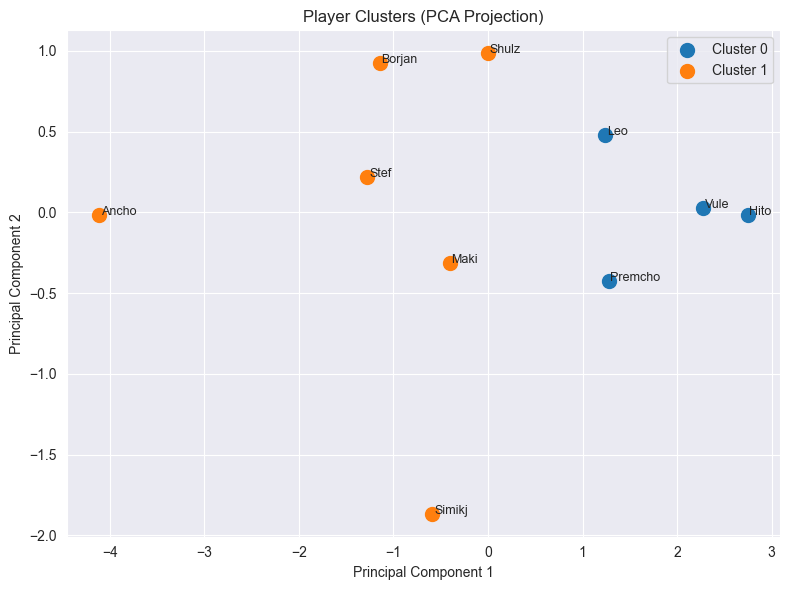

In [100]:
pairs = clustering_usage(set_of_features, match_outfield, 2)
clustered_tA, clustered_tB = make_teams_from_clusters(pairs)

print("Team A:", clustered_tA)
print("Team B:", clustered_tB)
plot_clusters(set_of_features,match_outfield)